In [1]:
import os
import time

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

from Tahoe_utils import Tahoe100M_split

In [3]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"

Load data:

In [4]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))
expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs.drug)) != len(tf_adata.obs.drug.cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs.cell_line)) != len(tf_adata.obs.cell_line.cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train/test split:

In [5]:
train_split, test_split = Tahoe100M_split(tf_adata,
                                          train_frac = 0.9, 
                                          min_drug_frac = 0.7, 
                                          min_cell_line_frac = 0.7, 
                                          exclude_control = True, 
                                          max_attempts = 1000, 
                                          seed = seed)

train_cells = train_split['barcodes']
test_cells = test_split['barcodes']

cell_line_counts = pd.DataFrame({
    'train': train_split['cell_line_counts'],
    'test': test_split['cell_line_counts']
}).sort_values(by = 'train', ascending = True)

drug_counts = pd.DataFrame({
    'train': train_split['drug_counts'],
    'test': test_split['drug_counts']
}).sort_values(by = 'train', ascending = True)



In [6]:
cell_line_counts

,train,test
cell_line,,
CVCL_0371,23,6
CVCL_0546,24,5
CVCL_1056,24,5
CVCL_0480,26,3
CVCL_1550,26,3
CVCL_0459,27,2
CVCL_1285,27,2
CVCL_0023,28,1
CVCL_0399,28,1


In [7]:
drug_counts

,train,test
drug,,
Neratinib (maleate),8,2
Almonertinib (mesylate),8,2
Tofacitinib (citrate),8,2
Rucaparib (phosphate),8,2
Retinoic acid,8,2
Rapamycin,8,2
Norepinephrine (hydrochloride),8,2
Filgotinib,8,2
Tofacitinib,9,1


**Note: As mentioned in Notebook 00A, when splitting the data into train-test splits, conditions will remain balanced, but drug/cell lines will not be completely balanced (due to OOD, cannot ensure the drug and cell line split is the same as the condition split).** 

# Hyper-parameters:

In [16]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts = 4,
                       n_discriminator_train=5, 
                       n_adversarial_start = 0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    Parameters:
        - n_epochs: total training epochs
        - max_lr: peak learning rate
        - lr_scaling_factor: factor to determine min LR
        - lr_decay: gamma decay per restart
        - n_restarts: desired number of cosine peaks (n_restarts)
        - n_adversarial_start: epoch when adversarial training begins
        - n_discriminator_train: frequency of discriminator training relative to generator
        - role: 'scl' or discriminator' or 'generator'

    Returns:
        Dict of scheduler parameters
    """
    
    
    
    total_active_epochs = n_epochs
    n_discriminator_train_ = 1
    if role in ['discriminator', 'generator']:
        total_active_epochs = n_epochs - n_adversarial_start
        if role == 'generator':
            n_discriminator_train_ = n_discriminator_train
            
#     n_restarts = 4 if total_active_epochs // n_discriminator_train_ > 500 else 2


    T_0 = max(1, (total_active_epochs // n_discriminator_train_) // n_restarts)
    warmup_epochs = max(1, (total_active_epochs // n_discriminator_train_) // 10)

#     if reset_state:
#         if total_active_epochs // n_discriminator_train_ > 400:
#             n_optimizer_resets = 2
#         elif total_active_epochs // n_discriminator_train_ < 100:
#             n_optimizer_resets = 0
#         else:
#             n_optimizer_resets = 1
#     else:
#         n_optimizer_resets = 0
        
    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,  
        'n_optimizer_resets': 0,  # no longer used
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }

In [17]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0015, #0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}

In [18]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')
per_condition_loss = False # TODO: check this


batch_params = {
    'train_batch_size': int(512*8), 
    'test_batch_size': int(512*8), 
    'validation_batch_size': np.nan
}

max_epochs = 600

max_lr = 0.001
lr_scaling_factor = 10
lr_decay = 0.75
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
                               n_discriminator_train = np.nan, 
                               role = 'scl')

# reset_state = False # DEPRECATED
# initialize_fc = True # DEPRECATED

In [19]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': 1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': 1e-6,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': 0, # using cat max norm
    'cat_bias_lambda_L1': 0, # using cat max norm
    'cat_bias_orthogonality_scaler': 0
}

In [20]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

VAE:

In [21]:
# building
n_layers_vae = 1
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': 1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

n_adversarial_start = 0 
n_discriminator_train = 5
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                                   n_adversarial_start = n_adversarial_start, 
                                   n_discriminator_train = n_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


Discriminator:

In [22]:
discriminator_dropout_rate = 0.3
discriminator_lambda_L2 = 1e-3

discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': False,
    'dropout_rate': discriminator_dropout_rate,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': discriminator_lambda_L2,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}

discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
    n_discriminator_train = n_discriminator_train,
    role = 'discriminator')
del discriminator_lr_params['max_epochs']

discriminator_params = {**discriminator_params, **discriminator_lr_params}

In [23]:
# architecture
n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    cell_line_counts.shape[0],
                                                    n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes


pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts.shape[0], 
                                                     n_layers_disc + 2)).astype(int)[1:-1])
pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes


cat_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.cell_line.nunique()
pert_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.drug.nunique()

In [24]:
# adverserial penalty curve
cat_max_penalty_weight = 11
cat_b_adv = 2.5
pert_max_penalty_weight = 15
pert_b_adv = 4

cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = cat_max_penalty_weight,
    a = 1,
    b = cat_b_adv, 
    curve_type = 'power')
cat_discriminator_params['discriminator_penalty_weight'] = cat_discriminator_penalty_weight

pert_discriminator_penalty_weight = pp.discriminator_weight_curve(
    n_epochs = max_epochs - n_adversarial_start,
    min_penalty_weight = 0.1,
    max_penalty_weight = pert_max_penalty_weight,
    a = 1,
    b = pert_b_adv, 
    curve_type = 'power')
pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight



Visualize hyperparameters:

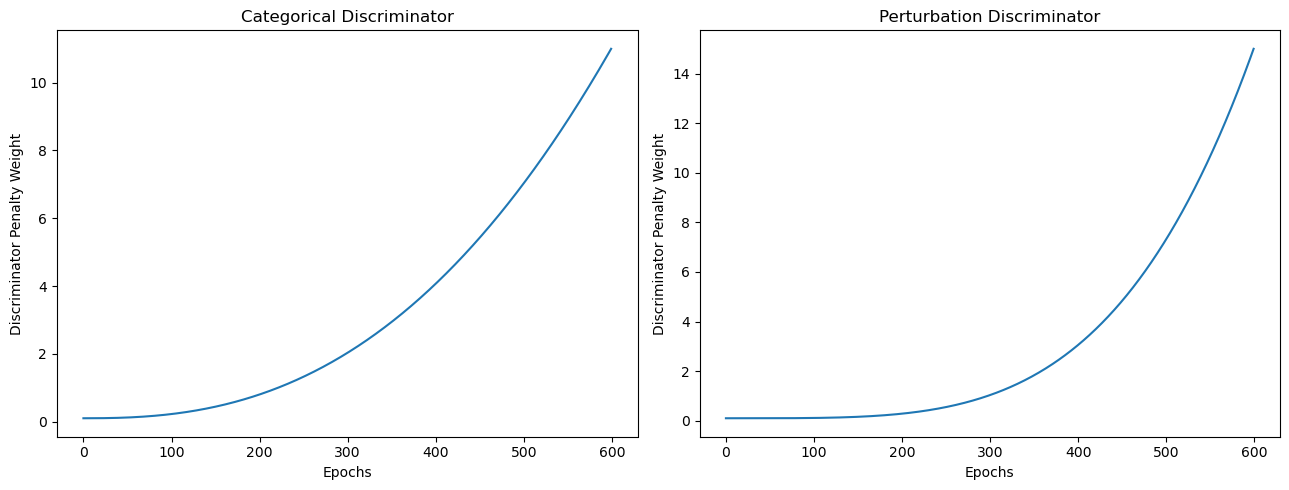

In [25]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

In [26]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs.drug).astype(int)
X_in.drop(columns = 'DMSO_TF', inplace = True) # all 0s

In [27]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = ['cell_line'],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [28]:
%%time
trainer = TrainSC(
    mod = mod,
    prediction_optimizer = torch.optim.Adam,
    prediction_loss_fn = prediction_loss_fn, 
    per_condition_loss = per_condition_loss,
    n_adversarial_start = n_adversarial_start, 
    n_discriminator_train = n_discriminator_train,
    gradient_ascent = True,
    cat_discriminator_params = cat_discriminator_params,
    pert_discriminator_params = pert_discriminator_params,
    vae_params = vae_params,
    hyper_params = training_params,
    train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
    train_seed = mod_seed, 
    track_test = True,
    track_validation = False, 
    n_eval_cells = np.nan, 
    n_eval_bootstrap = np.nan
)

CPU times: user 2.67 s, sys: 156 ms, total: 2.83 s
Wall time: 2.5 s


In [ ]:
mod = trainer.train_model(verbose = True)

  0%|                                 | 1/600 [00:07<1:18:30,  7.86s/it]

i=0, l(tr)=91.24494, l(te)=nan, s=0.15321, r=0.00010, v=0.00000


In [34]:
io.write_pickled_object(trainer, 
                        os.path.join(data_path, 'processed', author + '_trained_model.pickle')
                        


In [37]:
trainer.stats['train'].tail()

,epoch,batch_index,learning_rate,cat_discriminator_learning_rate,pert_discriminator_learning_rate,vae_learning_rate,iter_time,spectral_radius,n_moa_violations,train_loss_total,...,cat_adverserial_loss,cat_discriminator_loss_total,cat_discriminator_loss_prediction,cat_discriminator_param_reg_loss,cat_cell_line_discriminator_grad_l2_norm,pert_adverserial_loss,pert_discriminator_loss_total,pert_discriminator_loss_prediction,pert_discriminator_param_reg_loss,pert_discriminator_grad_l2_norm
3595,600.0,1.0,0.000218,0.000218,0.000218,0.000227,5064.963757,0.204784,1.0,36.039963,...,0.0,1.758006,1.556844,0.201162,1.205463,0.0,3.162334,2.967505,0.194829,1.370231
3596,600.0,2.0,0.000218,0.000218,0.000218,0.000227,5065.991420,0.184943,0.0,35.512123,...,0.0,1.735271,1.534116,0.201155,0.978123,0.0,3.167316,2.972494,0.194822,1.330077
3597,600.0,3.0,0.000218,0.000218,0.000218,0.000227,5066.781665,0.150181,0.0,35.511612,...,0.0,1.736001,1.534850,0.201151,1.029348,0.0,3.168424,2.973609,0.194815,1.265357
3598,600.0,4.0,0.000218,0.000218,0.000218,0.000227,5067.643818,0.154058,0.0,35.954926,...,0.0,1.720691,1.519541,0.201151,0.938043,0.0,3.167050,2.972240,0.194810,1.329070
3599,600.0,5.0,0.000218,0.000218,0.000218,0.000227,5068.296789,0.257295,0.0,35.062527,...,0.0,1.742453,1.541298,0.201155,1.482827,0.0,3.201096,3.006288,0.194808,1.953535


In [38]:
5068.296789/60

84.47161315